# GGA Network Training Example

This notebook demonstrates how to train a GGA-level exchange-correlation functional using xcquinox.

## Outline

1. **Setup**: Import libraries and define helper functions
2. **Pre-training**: Train exchange (X) and correlation (C) networks on reference functional data (PBE)
3. **Training Part I**: Train on total energies of atoms + atomization energies of small molecules
4. **Training Part II**: Include density error in the loss function

All calculations use PySCF-AD (autodifferentiable PySCF) as the calculation driver.

---
## 1. Setup

In [1]:
# Core imports
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import matplotlib.pyplot as plt

# PySCF imports
import pyscf
from pyscf import gto, dft, scf

# PySCF-AD imports (autodifferentiable)
import pyscfad
from pyscfad import gto as gto_ad
from pyscfad import dft as dft_ad

# xcquinox imports
import xcquinox as xce
from xcquinox.train import Pretrainer, Optimizer
from xcquinox.utils import lda_x, pw92c_unpolarized
from functools import partial

# ASE for molecular structures
from ase import Atoms

# Enable 64-bit precision for stability
jax.config.update("jax_enable_x64", True)

print(f"JAX version: {jax.__version__}")
print(f"PySCF version: {pyscf.__version__}")
print(f"PySCF-AD version: {pyscfad.__version__}")
print(f"Using device: {jax.devices()[0]}")

JAX version: 0.7.0
PySCF version: 2.11.0
PySCF-AD version: 0.1.11
Using device: TFRT_CPU_0


In [ ]:
# Configuration - keep computations affordable
BASIS = 'sto-3g'           # Small basis for speed
GRID_LEVEL = 1             # Coarse grid for speed
REFERENCE_XC = 'PBE'       # Reference functional for pre-training

# Use CPU to avoid GPU memory issues
CPU_DEVICE = jax.devices('cpu')[0]

# Spin configurations for isolated atoms
SPINS_DICT = {
    'H': 1, 'He': 0, 'Li': 1, 'Be': 0, 'B': 1, 'C': 2, 'N': 3, 'O': 2, 'F': 1, 'Ne': 0,
    'Na': 1, 'Mg': 0, 'Al': 1, 'Si': 2, 'P': 3, 'S': 2, 'Cl': 1, 'Ar': 0
}

# Checkpoint directory structure
import os
CHECKPOINT_BASE = 'checkpoints'
CHECKPOINT_DIRS = {
    'pretrain_xnet_A': os.path.join(CHECKPOINT_BASE, '01_pretrain_xnet_A'),
    'pretrain_cnet_A': os.path.join(CHECKPOINT_BASE, '02_pretrain_cnet_A'),
    'pretrain_xnet_B': os.path.join(CHECKPOINT_BASE, '03_pretrain_xnet_B'),
    'pretrain_cnet_B': os.path.join(CHECKPOINT_BASE, '04_pretrain_cnet_B'),
    'train_energy': os.path.join(CHECKPOINT_BASE, '05_train_energy'),
    'train_energy_density': os.path.join(CHECKPOINT_BASE, '06a_train_energy_density'),
    'train_energy_density_hw': os.path.join(CHECKPOINT_BASE, '06b_train_energy_density_hw'),
    'train_grid_density': os.path.join(CHECKPOINT_BASE, '07_train_grid_density'),
    'final_models': os.path.join(CHECKPOINT_BASE, '08_final_models'),
}

# Create all checkpoint directories
for name, path in CHECKPOINT_DIRS.items():
    os.makedirs(path, exist_ok=True)
    print(f"Checkpoint dir: {path}")

print(f"\nAll checkpoints will be saved under: {CHECKPOINT_BASE}/")

In [3]:
def create_mol(atoms_str, basis=BASIS, charge=0, spin=None):
    '''
    Create a PySCF Mole object from atom string.
    
    :param atoms_str: Atom specification (e.g., 'H 0 0 0; H 0 0 0.74')
    :param basis: Basis set name
    :param charge: Molecular charge
    :param spin: 2S (number of unpaired electrons), auto-detected for single atoms
    :return: Built PySCF Mole object
    '''
    mol = gto.Mole()
    mol.atom = atoms_str
    mol.basis = basis
    mol.charge = charge
    if spin is not None:
        mol.spin = spin
    mol.build()
    return mol


def create_mol_ad(atoms_str, basis=BASIS, charge=0, spin=None):
    '''
    Create a PySCF-AD Mole object (autodifferentiable).
    
    :param atoms_str: Atom specification (e.g., 'H 0 0 0; H 0 0 0.74')
    :param basis: Basis set name
    :param charge: Molecular charge
    :param spin: 2S (number of unpaired electrons)
    :return: Built PySCF-AD Mole object
    '''
    mol = gto_ad.Mole()  # Fixed: was gtoad, now gto_ad
    mol.atom = atoms_str
    mol.basis = basis
    mol.charge = charge
    if spin is not None:
        mol.spin = spin
    mol.build()
    return mol


def run_pbe_calculation(mol):
    '''
    Run a standard PBE DFT calculation.
    
    :param mol: PySCF Mole object
    :return: Converged mf object
    '''
    if mol.spin == 0:
        mf = dft.RKS(mol)
    else:
        mf = dft.UKS(mol)
    mf.xc = REFERENCE_XC
    mf.grids.level = GRID_LEVEL
    mf.kernel()
    return mf


def get_enhancement_factor_data(mol, mf, xorc='x'):
    '''
    Extract enhancement factor data from a converged calculation for pre-training.

    :param mol: PySCF Mole object
    :param mf: Converged mf object
    :param xorc: 'x' for exchange or 'c' for correlation
    :return: (descriptors, reference_enhancement_factors)
    '''
    ao = mf._numint.eval_ao(mol, mf.grids.coords, deriv=1)
    dm = mf.make_rdm1()

    # Handle spin - for UKS, dm has shape (2, nao, nao)
    if len(dm.shape) == 2:
        # RKS: split into alpha/beta
        dm_alpha = dm * 0.5
        dm_beta = dm * 0.5
    else:
        # UKS: already split
        dm_alpha = dm[0]
        dm_beta = dm[1]

    # Evaluate density on grid (GGA format: rho, grad_x, grad_y, grad_z)
    rho_alpha = mf._numint.eval_rho(mol, ao, dm_alpha, xctype='GGA', hermi=True)
    rho_beta = mf._numint.eval_rho(mol, ao, dm_beta, xctype='GGA', hermi=True)

    # Extract density and gradient components
    rho0_a = rho_alpha[0]  # density
    rho0_b = rho_beta[0]
    drho_a = rho_alpha[1:4]  # gradients
    drho_b = rho_beta[1:4]

    # Total density and sigma for descriptors
    rho0 = rho0_a + rho0_b
    sigma = np.sum((drho_a + drho_b)**2, axis=0)

    if xorc == 'x':
        # Exchange: Fx = exc / lda_x (spin=0 for unpolarized reference)
        xc_func = f'{REFERENCE_XC},'
        # For GGA eval_xc with spin=0, pass total density in GGA format
        rho_total = rho_alpha + rho_beta  # Total in GGA format (4, ngrids)
        exc = mf._numint.eval_xc(xc_func, rho_total, spin=0)[0]
        lda_exc = mf._numint.eval_xc('LDA_X,', rho0, spin=0)[0]
        Fxc = exc / (lda_exc + 1e-10) - 1  # Enhancement factor minus 1
    else:
        # Correlation: Fc = ec / lda_c
        xc_func = f',{REFERENCE_XC}'
        rho_total = rho_alpha + rho_beta
        exc = mf._numint.eval_xc(xc_func, rho_total, spin=0)[0]
        lda_exc = mf._numint.eval_xc(',LDA_C_PW', rho0, spin=0)[0]
        Fxc = exc / (lda_exc + 1e-10) - 1

    # Filter out low-density regions
    valid = rho0 > 1e-6
    rho0 = rho0[valid]
    sigma = sigma[valid]
    Fxc = Fxc[valid]

    # Stack as input features [rho, sigma]
    descriptors = np.stack([rho0, sigma], axis=1)

    return jnp.array(descriptors), jnp.array(Fxc)

---
## 2. Pre-training

Pre-training fits the neural network enhancement factors (Fx and Fc) to reproduce a reference functional (PBE) on a set of atoms and small molecules.

We'll explore two different network architectures:
- **Architecture A**: Shallow network (depth=2, nodes=8)
- **Architecture B**: Deeper network (depth=3, nodes=16)

In [4]:
# Define pre-training molecules (small atoms and diatomics)
pretrain_systems = [
    ('H', 1),      # Hydrogen atom
    ('C', 2),      # Carbon atom
    ('N', 3),      # Nitrogen atom
    ('O', 2),      # Oxygen atom
    ('H 0 0 0; H 0 0 0.74', 0),   # H2
    ('N 0 0 0; N 0 0 1.1', 0),     # N2
    ('O 0 0 0; O 0 0 1.21', 2),    # O2 (triplet)
]

print("Pre-training molecules:")
for atoms, spin in pretrain_systems:
    print(f"  {atoms} (spin={spin})")

Pre-training molecules:
  H (spin=1)
  C (spin=2)
  N (spin=3)
  O (spin=2)
  H 0 0 0; H 0 0 0.74 (spin=0)
  N 0 0 0; N 0 0 1.1 (spin=0)
  O 0 0 0; O 0 0 1.21 (spin=2)


In [5]:
# Collect enhancement factor data from reference calculations
print("Running reference calculations and collecting enhancement factor data...")

all_descriptors_x = []
all_Fx = []
all_descriptors_c = []
all_Fc = []

for atoms_str, spin in pretrain_systems:
    print(f"  Processing: {atoms_str}")
    mol = create_mol(atoms_str, spin=spin)
    mf = run_pbe_calculation(mol)
    
    # Exchange data
    desc_x, Fx = get_enhancement_factor_data(mol, mf, xorc='x')
    all_descriptors_x.append(desc_x)
    all_Fx.append(Fx)
    
    # Correlation data
    desc_c, Fc = get_enhancement_factor_data(mol, mf, xorc='c')
    all_descriptors_c.append(desc_c)
    all_Fc.append(Fc)

# Concatenate all data
train_desc_x = jnp.concatenate(all_descriptors_x, axis=0)
train_Fx = jnp.concatenate(all_Fx, axis=0)
train_desc_c = jnp.concatenate(all_descriptors_c, axis=0)
train_Fc = jnp.concatenate(all_Fc, axis=0)

print(f"\nCollected data shapes:")
print(f"  Exchange descriptors: {train_desc_x.shape}")
print(f"  Exchange Fx targets: {train_Fx.shape}")
print(f"  Correlation descriptors: {train_desc_c.shape}")
print(f"  Correlation Fc targets: {train_Fc.shape}")

Running reference calculations and collecting enhancement factor data...
  Processing: H
converged SCF energy = -0.464375662953948  <S^2> = 0.75  2S+1 = 2
  Processing: C
converged SCF energy = -37.2868344698624  <S^2> = 2  2S+1 = 3
  Processing: N
converged SCF energy = -53.814703131493  <S^2> = 3.75  2S+1 = 4
  Processing: O
converged SCF energy = -73.9487681346346  <S^2> = 2  2S+1 = 3
  Processing: H 0 0 0; H 0 0 0.74
converged SCF energy = -1.15207386040247
  Processing: N 0 0 0; N 0 0 1.1
converged SCF energy = -107.928182006105
  Processing: O 0 0 0; O 0 0 1.21
converged SCF energy = -148.138372397661  <S^2> = 2.0003916  2S+1 = 3.000261

Collected data shapes:
  Exchange descriptors: (33650, 2)
  Exchange Fx targets: (33650,)
  Correlation descriptors: (33650, 2)
  Correlation Fc targets: (33650,)


In [6]:
class PretrainLoss(eqx.Module):
    '''
    MSE loss for pre-training enhancement factor networks.
    '''
    def __call__(self, model, descriptors, ref_F):
        '''
        Compute MSE loss between predicted and reference enhancement factors.
        
        :param model: GGA network (GGA_FxNet_sigma or GGA_FcNet_sigma)
        :param descriptors: Input descriptors shape (N, 2) with [rho, sigma] per row
        :param ref_F: Reference enhancement factors shape (N,)
        :return: MSE loss
        '''
        # Networks expect one grid point at a time: inputs[0]=rho, inputs[1]=sigma
        # Use vmap to process each row of (N, 2) array
        # Each call to model gets a (2,) array where inputs[0]=rho, inputs[1]=sigma
        pred = jax.vmap(model)(descriptors)  # Shape (N,)
        # Subtract 1 because networks output 1 + enhancement
        pred = pred - 1.0
        return jnp.mean((pred - ref_F)**2)

### Architecture A: Shallow Network (depth=2, nodes=8)

In [7]:
# Create shallow networks
DEPTH_A = 2
NODES_A = 8
SEED = 42

# Exchange network
xnet_A = xce.net.GGA_FxNet_sigma(depth=DEPTH_A, nodes=NODES_A, seed=SEED)
print(f"Exchange Network A: depth={DEPTH_A}, nodes={NODES_A}")

# Correlation network
cnet_A = xce.net.GGA_FcNet_sigma(depth=DEPTH_A, nodes=NODES_A, seed=SEED)
print(f"Correlation Network A: depth={DEPTH_A}, nodes={NODES_A}")

Exchange Network A: depth=2, nodes=8
Correlation Network A: depth=2, nodes=8


In [8]:
# Pre-train Architecture A
print("Pre-training Architecture A...")

PRETRAIN_STEPS = 100  # Reduced for debugging
PRETRAIN_LR = 1e-2

# Learning rate schedule with decay
scheduler = optax.exponential_decay(
    init_value=PRETRAIN_LR,
    transition_begin=50,
    transition_steps=200,
    decay_rate=0.9
)
optimizer = optax.adam(learning_rate=scheduler)
loss_fn = PretrainLoss()

# Train exchange network
print("\n--- Training Exchange Network A ---")
os.chdir(CHECKPOINT_DIRS['pretrain_xnet_A'])  # Change to checkpoint dir for xcTrainer saves
trainer_x = xce.train.xcTrainer(
    model=xnet_A,
    optim=optimizer,
    steps=PRETRAIN_STEPS,
    loss=loss_fn,
    do_jit=True
)

with jax.default_device(CPU_DEVICE):
    xnet_A_trained = trainer_x(1, xnet_A, [train_desc_x], [train_Fx])

# Save final trained model
eqx.tree_serialise_leaves('xnet_A_final.eqx', xnet_A_trained)
print(f"Saved xnet_A to {CHECKPOINT_DIRS['pretrain_xnet_A']}/xnet_A_final.eqx")
os.chdir('../..')  # Return to notebooks dir

# Train correlation network
print("\n--- Training Correlation Network A ---")
os.chdir(CHECKPOINT_DIRS['pretrain_cnet_A'])
trainer_c = xce.train.xcTrainer(
    model=cnet_A,
    optim=optimizer,
    steps=PRETRAIN_STEPS,
    loss=loss_fn,
    do_jit=True
)

with jax.default_device(CPU_DEVICE):
    cnet_A_trained = trainer_c(1, cnet_A, [train_desc_c], [train_Fc])

# Save final trained model
eqx.tree_serialise_leaves('cnet_A_final.eqx', cnet_A_trained)
print(f"Saved cnet_A to {CHECKPOINT_DIRS['pretrain_cnet_A']}/cnet_A_final.eqx")
os.chdir('../..')

Pre-training Architecture A...

--- Training Exchange Network A ---
Epoch 0
Step = 0: initializing inp_model and inp_opt_state.
Epoch 0 :: Batch 1/1
s shape (1,)
Batch Loss = 0.3068730802635183
0, epoch_train_loss=0.3068730802635183
Epoch 1
Epoch 1 :: Batch 1/1
s shape (1,)
Batch Loss = 0.23843063260740754
1, epoch_train_loss=0.23843063260740754
Epoch 2
Epoch 2 :: Batch 1/1
s shape (1,)
Batch Loss = 0.1593106427517744
2, epoch_train_loss=0.1593106427517744
Epoch 3
Epoch 3 :: Batch 1/1
s shape (1,)
Batch Loss = 0.08886640535505008
3, epoch_train_loss=0.08886640535505008
Epoch 4
Epoch 4 :: Batch 1/1
s shape (1,)
Batch Loss = 0.05327895365514796
4, epoch_train_loss=0.05327895365514796
Epoch 5
Epoch 5 :: Batch 1/1
s shape (1,)
Batch Loss = 0.03870906478498957
5, epoch_train_loss=0.03870906478498957
Epoch 6
Epoch 6 :: Batch 1/1
s shape (1,)
Batch Loss = 0.03059139228118858
6, epoch_train_loss=0.03059139228118858
Epoch 7
Epoch 7 :: Batch 1/1
s shape (1,)
Batch Loss = 0.02498863144649283
7, e

### Architecture B: Deeper Network (depth=3, nodes=16)

In [9]:
# Create deeper networks
DEPTH_B = 3
NODES_B = 16

# Exchange network
xnet_B = xce.net.GGA_FxNet_sigma(depth=DEPTH_B, nodes=NODES_B, seed=SEED)
print(f"Exchange Network B: depth={DEPTH_B}, nodes={NODES_B}")

# Correlation network  
cnet_B = xce.net.GGA_FcNet_sigma(depth=DEPTH_B, nodes=NODES_B, seed=SEED)
print(f"Correlation Network B: depth={DEPTH_B}, nodes={NODES_B}")

Exchange Network B: depth=3, nodes=16
Correlation Network B: depth=3, nodes=16


In [10]:
# Pre-train Architecture B
print("Pre-training Architecture B...")

# Train exchange network
print("\n--- Training Exchange Network B ---")
os.chdir(CHECKPOINT_DIRS['pretrain_xnet_B'])
trainer_x_B = xce.train.xcTrainer(
    model=xnet_B,
    optim=optimizer,
    steps=PRETRAIN_STEPS,
    loss=loss_fn,
    do_jit=True
)

with jax.default_device(CPU_DEVICE):
    xnet_B_trained = trainer_x_B(1, xnet_B, [train_desc_x], [train_Fx])

# Save final trained model
eqx.tree_serialise_leaves('xnet_B_final.eqx', xnet_B_trained)
print(f"Saved xnet_B to {CHECKPOINT_DIRS['pretrain_xnet_B']}/xnet_B_final.eqx")
os.chdir('../..')

# Train correlation network
print("\n--- Training Correlation Network B ---")
os.chdir(CHECKPOINT_DIRS['pretrain_cnet_B'])
trainer_c_B = xce.train.xcTrainer(
    model=cnet_B,
    optim=optimizer,
    steps=PRETRAIN_STEPS,
    loss=loss_fn,
    do_jit=True
)

with jax.default_device(CPU_DEVICE):
    cnet_B_trained = trainer_c_B(1, cnet_B, [train_desc_c], [train_Fc])

# Save final trained model
eqx.tree_serialise_leaves('cnet_B_final.eqx', cnet_B_trained)
print(f"Saved cnet_B to {CHECKPOINT_DIRS['pretrain_cnet_B']}/cnet_B_final.eqx")
os.chdir('../..')

Pre-training Architecture B...

--- Training Exchange Network B ---
Epoch 0
Step = 0: initializing inp_model and inp_opt_state.
Epoch 0 :: Batch 1/1
s shape (1,)
Batch Loss = 0.04710782817113694
0, epoch_train_loss=0.04710782817113694
Epoch 1
Epoch 1 :: Batch 1/1
s shape (1,)
Batch Loss = 0.025087755391933177
1, epoch_train_loss=0.025087755391933177
Epoch 2
Epoch 2 :: Batch 1/1
s shape (1,)
Batch Loss = 0.01219173715663638
2, epoch_train_loss=0.01219173715663638
Epoch 3
Epoch 3 :: Batch 1/1
s shape (1,)
Batch Loss = 0.004594894805114316
3, epoch_train_loss=0.004594894805114316
Epoch 4
Epoch 4 :: Batch 1/1
s shape (1,)
Batch Loss = 0.000878088192426178
4, epoch_train_loss=0.000878088192426178
Epoch 5
Epoch 5 :: Batch 1/1
s shape (1,)
Batch Loss = 4.008352417300643e-05
5, epoch_train_loss=4.008352417300643e-05
Epoch 6
Epoch 6 :: Batch 1/1
s shape (1,)
Batch Loss = 0.001018600033422291
6, epoch_train_loss=0.001018600033422291
Epoch 7
Epoch 7 :: Batch 1/1
s shape (1,)
Batch Loss = 0.002701

In [11]:
# Compare pre-training results
print("\n" + "="*60)
print("Pre-training Results Comparison")
print("="*60)

# Evaluate on training data - use vmap to process each grid point
# Networks expect (2,) input per point: [rho, sigma]
pred_Fx_A = jax.vmap(xnet_A_trained)(train_desc_x) - 1.0
pred_Fx_B = jax.vmap(xnet_B_trained)(train_desc_x) - 1.0
pred_Fc_A = jax.vmap(cnet_A_trained)(train_desc_c) - 1.0
pred_Fc_B = jax.vmap(cnet_B_trained)(train_desc_c) - 1.0

rmse_Fx_A = jnp.sqrt(jnp.mean((pred_Fx_A - train_Fx)**2))
rmse_Fx_B = jnp.sqrt(jnp.mean((pred_Fx_B - train_Fx)**2))
rmse_Fc_A = jnp.sqrt(jnp.mean((pred_Fc_A - train_Fc)**2))
rmse_Fc_B = jnp.sqrt(jnp.mean((pred_Fc_B - train_Fc)**2))

print(f"\nExchange Enhancement Factor RMSE:")
print(f"  Architecture A (depth={DEPTH_A}, nodes={NODES_A}): {rmse_Fx_A:.6f}")
print(f"  Architecture B (depth={DEPTH_B}, nodes={NODES_B}): {rmse_Fx_B:.6f}")

print(f"\nCorrelation Enhancement Factor RMSE:")
print(f"  Architecture A (depth={DEPTH_A}, nodes={NODES_A}): {rmse_Fc_A:.6f}")
print(f"  Architecture B (depth={DEPTH_B}, nodes={NODES_B}): {rmse_Fc_B:.6f}")


Pre-training Results Comparison
s shape (1,)
s shape (1,)

Exchange Enhancement Factor RMSE:
  Architecture A (depth=2, nodes=8): 0.002330
  Architecture B (depth=3, nodes=16): 0.004318

Correlation Enhancement Factor RMSE:
  Architecture A (depth=2, nodes=8): 0.048048
  Architecture B (depth=3, nodes=16): 0.027038


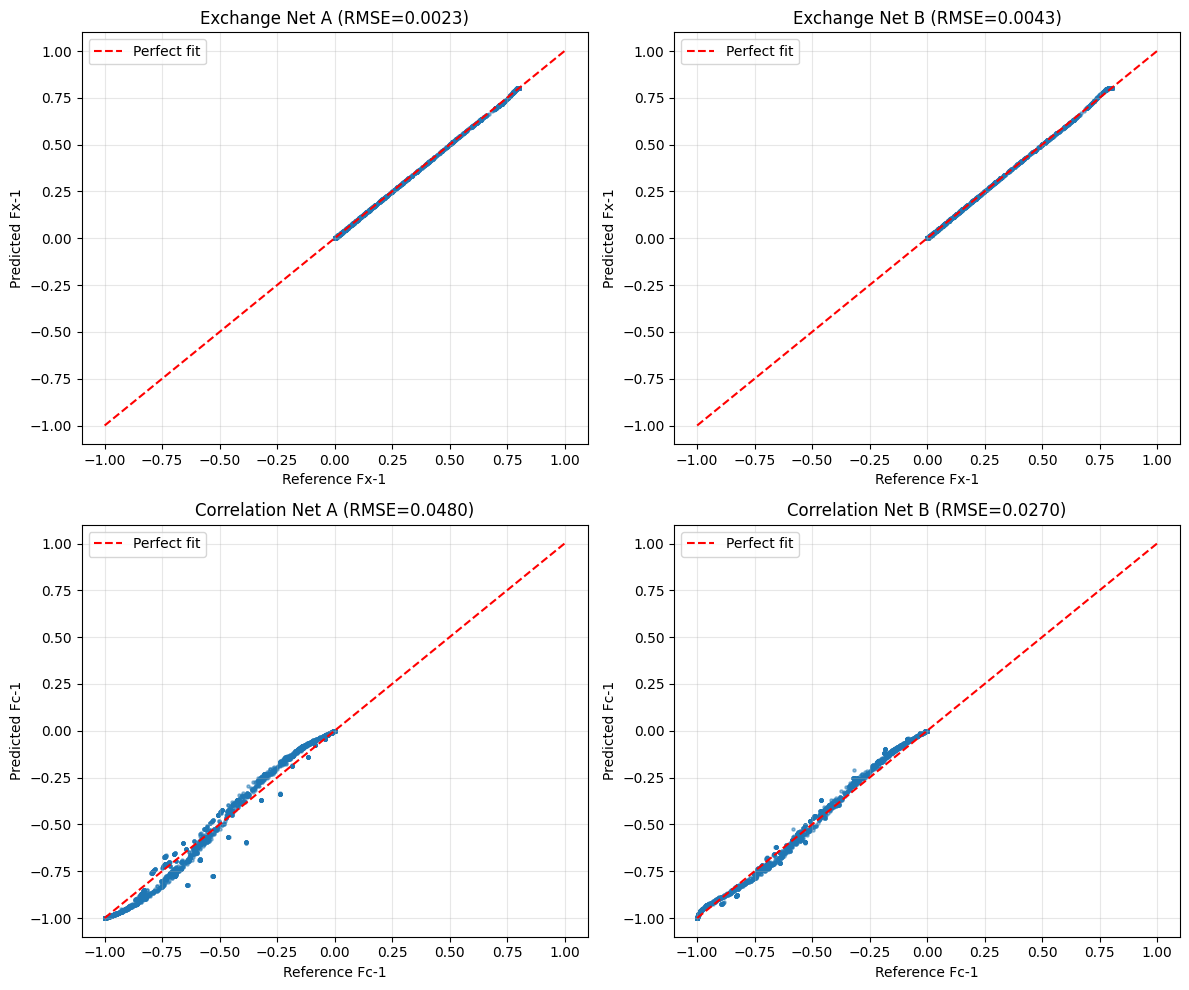

In [12]:
# Visualize pre-training results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Exchange - Architecture A
ax = axes[0, 0]
ax.scatter(train_Fx[::10], pred_Fx_A[::10], alpha=0.5, s=5)
ax.plot([-1, 1], [-1, 1], 'r--', label='Perfect fit')
ax.set_xlabel('Reference Fx-1')
ax.set_ylabel('Predicted Fx-1')
ax.set_title(f'Exchange Net A (RMSE={rmse_Fx_A:.4f})')
ax.legend()
ax.grid(True, alpha=0.3)

# Exchange - Architecture B
ax = axes[0, 1]
ax.scatter(train_Fx[::10], pred_Fx_B[::10], alpha=0.5, s=5)
ax.plot([-1, 1], [-1, 1], 'r--', label='Perfect fit')
ax.set_xlabel('Reference Fx-1')
ax.set_ylabel('Predicted Fx-1')
ax.set_title(f'Exchange Net B (RMSE={rmse_Fx_B:.4f})')
ax.legend()
ax.grid(True, alpha=0.3)

# Correlation - Architecture A
ax = axes[1, 0]
ax.scatter(train_Fc[::10], pred_Fc_A[::10], alpha=0.5, s=5)
ax.plot([-1, 1], [-1, 1], 'r--', label='Perfect fit')
ax.set_xlabel('Reference Fc-1')
ax.set_ylabel('Predicted Fc-1')
ax.set_title(f'Correlation Net A (RMSE={rmse_Fc_A:.4f})')
ax.legend()
ax.grid(True, alpha=0.3)

# Correlation - Architecture B
ax = axes[1, 1]
ax.scatter(train_Fc[::10], pred_Fc_B[::10], alpha=0.5, s=5)
ax.plot([-1, 1], [-1, 1], 'r--', label='Perfect fit')
ax.set_xlabel('Reference Fc-1')
ax.set_ylabel('Predicted Fc-1')
ax.set_title(f'Correlation Net B (RMSE={rmse_Fc_B:.4f})')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3. Training Part I: Total Energies and Atomization Energies

Now we fine-tune the pre-trained networks on:
1. Total energies of atoms (compared to reference CCSD(T) or high-accuracy DFT)
2. Atomization energies of small molecules

We use PySCF-AD to enable gradient-based optimization through the SCF cycle.

In [13]:
# Create combined XC model from pre-trained networks
# We'll use Architecture B (deeper network) for training

def lda_c_pw(rhoa, rhob):
    '''PW92 LDA correlation for spin-polarized systems.'''
    params_a_pp = [1, 1, 1]
    params_a_a = [0.031091, 0.015545, 0.016887]
    params_a_alpha1 = [0.21370, 0.20548, 0.11125]
    params_a_beta1 = [7.5957, 14.1189, 10.357]
    params_a_beta2 = [3.5876, 6.1977, 3.6231]
    params_a_beta3 = [1.6382, 3.3662, 0.88026]
    params_a_beta4 = [0.49294, 0.62517, 0.49671]
    params_a_fz20 = 1.709921

    rho = rhoa + rhob
    zeta = (rhoa - rhob) / (rhoa + rhob + 1e-8)
    rs = (4 * jnp.pi * (rho + 1e-8) / 3)**(-1/3)

    def g_aux(k, rs):
        return params_a_beta1[k] * jnp.sqrt(rs) + params_a_beta2[k] * rs \
            + params_a_beta3[k] * rs**1.5 + params_a_beta4[k] * rs**(params_a_pp[k] + 1)

    def g(k, rs):
        return -2 * params_a_a[k] * (1 + params_a_alpha1[k] * rs) \
            * jnp.log(1 + 1 / (2 * params_a_a[k] * g_aux(k, rs)))

    def f_zeta(zeta):
        return ((1 + zeta)**(4/3) + (1 - zeta)**(4/3) - 2) / (2**(4/3) - 2)

    def f_pw(rs, zeta):
        return g(0, rs) + zeta**4 * f_zeta(zeta) * (g(1, rs) - g(0, rs) + g(2, rs) / params_a_fz20) \
            - f_zeta(zeta) * g(2, rs) / params_a_fz20

    return f_pw(rs, zeta)


class RXCModel_GGA(eqx.Module):
    '''
    Combined GGA XC model with exchange and correlation networks.
    
    Computes epsilon = rho * e_xc where e_xc = ex_lda * Fx + ec_lda * Fc.
    Works with both unpolarized and spin-polarized inputs.
    
    Input format: (N, D) where D=2 for unpolarized, D=5 for polarized, N=grid points
    Each row is one grid point: [rho, sigma] or [rho_a, rho_b, sigma_aa, sigma_ab, sigma_bb]
    
    The networks expect one grid point at a time, so vmap is used internally.
    '''
    xnet: eqx.Module
    cnet: eqx.Module

    def __init__(self, xnet, cnet):
        self.xnet = xnet
        self.cnet = cnet
    
    def _eval_single_point_unpol(self, point):
        '''Evaluate epsilon for a single unpolarized grid point.'''
        rho = point[0]
        sigma = point[1]
        
        ex_lda = lda_x(rho)
        ec_pw92 = pw92c_unpolarized(rho)
        
        rho_safe = jnp.maximum(rho, 1e-18)
        # Networks expect [rho, sigma] as input
        Fx = self.xnet(point)
        Fc = self.cnet(point)
        epsilon = rho_safe * (ex_lda * Fx + ec_pw92 * Fc)
        return epsilon
    
    def _eval_single_point_pol(self, point):
        '''Evaluate epsilon for a single polarized grid point.'''
        rho_a = point[0]
        rho_b = point[1]
        sigma_aa = point[2]
        sigma_ab = point[3]
        sigma_bb = point[4]
        
        rho = rho_a + rho_b
        sigma = sigma_aa + 2*sigma_ab + sigma_bb
        
        ex_lda = lda_x(rho)
        ec_pw92 = lda_c_pw(rho_a, rho_b)
        
        rho_safe = jnp.maximum(rho, 1e-18)
        # Networks expect [rho, sigma] - combine for network input
        net_input = jnp.array([rho, sigma])
        Fx = self.xnet(net_input)
        Fc = self.cnet(net_input)
        epsilon = rho_safe * (ex_lda * Fx + ec_pw92 * Fc)
        return epsilon
        
    def __call__(self, inputs):
        '''
        Compute epsilon = rho * e_xc.
        
        :param inputs: Shape (N, 2) for unpolarized or (N, 5) for polarized
                       Each row is one grid point
        :return: epsilon array of shape (N,)
        '''
        inputs = jnp.atleast_2d(inputs)
        
        # Check second dimension to determine polarization
        if inputs.shape[-1] == 2:
            # Unpolarized case: inputs shape (N, 2) with [rho, sigma] per row
            epsilon = jax.vmap(self._eval_single_point_unpol)(inputs)
            
        elif inputs.shape[-1] == 5:
            # Polarized case: inputs shape (N, 5) 
            epsilon = jax.vmap(self._eval_single_point_pol)(inputs)
        else:
            raise ValueError(f"Unexpected input shape: {inputs.shape}. Expected (N, 2) or (N, 5)")
        
        return jnp.squeeze(epsilon)


# Create the XC model from pre-trained networks
xcmodel = RXCModel_GGA(xnet=xnet_B_trained, cnet=cnet_B_trained)
print("Created combined XC model from pre-trained Architecture B networks")

Created combined XC model from pre-trained Architecture B networks


In [14]:
# Training data: atoms and small molecules with reference energies
# Use pyscf-ad (gto_ad) for autodifferentiable molecules

# Define systems with atom specifications
training_systems = [
    # Atoms
    {'name': 'H', 'atoms': 'H 0 0 0', 'spin': 1, 'charge': 0, 'type': 'atom'},
    {'name': 'O', 'atoms': 'O 0 0 0', 'spin': 2, 'charge': 0, 'type': 'atom'},
    # Molecules
    {'name': 'H2O', 'atoms': 'O 0 0 0; H 0 0.757 0.587; H 0 -0.757 0.587', 
     'spin': 0, 'charge': 0, 'type': 'molecule', 'composition': {'H': 2, 'O': 1}},
]

# Reference energies (Hartree)
# H: -0.5 Ha (exact)
# O: -75.0673 Ha (high-level reference)
# H2O atomization: ~974.94 kJ/mol = ~0.371 Ha
kjMol_to_H = 2625.5
refs = {
    'H_TE': -0.5,
    'O_TE': -75.0673,
    'H2O_AE': -974.94 / kjMol_to_H  # Atomization energy (negative = exothermic)
}

# Build pyscf-ad molecules (autodifferentiable)
print("Building pyscf-ad molecules for training...")
mols_ad = []
mol_names = []

for system in training_systems:
    mol = gto_ad.Mole()
    mol.atom = system['atoms']
    mol.basis = BASIS
    mol.charge = system['charge']
    mol.spin = system['spin']
    mol.build()
    mol.max_memory = 32000
    mols_ad.append(mol)
    mol_names.append(system['name'])
    print(f"  Built {system['name']}: {mol.nelectron} electrons, spin={system['spin']}")

print(f"\nTotal {len(mols_ad)} molecules for training")
print(f"Reference energies: {refs}")

Building pyscf-ad molecules for training...
  Built H: 1 electrons, spin=1
  Built O: 8 electrons, spin=2
  Built H2O: 10 electrons, spin=0

Total 3 molecules for training
Reference energies: {'H_TE': -0.5, 'O_TE': -75.0673, 'H2O_AE': -0.37133498381260716}


In [15]:
# Define the custom eval_xc_gga_j2 function from gga_pol_dev.ipynb
# This handles BOTH polarized and unpolarized cases properly
# Uses vmap internally for per-grid-point network evaluation

def eval_xc_gga_j2(xc_code, rho, spin=0, relativity=0, deriv=1, omega=None, verbose=None,
                   xcmodel=None):
    '''
    Evaluate GGA exchange-correlation using a neural network model.
    
    Handles both spin-polarized and unpolarized cases.
    Uses vmap internally for per-grid-point evaluation.
    
    :param xc_code: XC functional code (ignored)
    :param rho: Density and gradients from PySCF
    :param spin: Spin polarization flag
    :param xcmodel: Combined XC model (RXCModel_GGA)
    :return: (exc, vxc, fxc, kxc)
    '''
    # Detect if spin-polarized by checking if rho is a tuple/list
    try:
        # Try unpolarized first
        rho0, dx, dy, dz = rho[:4]
        sigma = jnp.array(dx**2 + dy**2 + dz**2)
        rho0 = jnp.array(rho0)
        is_polarized = False
    except (ValueError, TypeError):
        # Spin-polarized: rho = [rho_a, rho_b]
        rho_a, rho_b = rho
        rho0a, dxa, dya, dza = rho_a[:4]
        rho0b, dxb, dyb, dzb = rho_b[:4]
        
        rho0 = rho0a + rho0b
        sigma_aa = dxa**2 + dya**2 + dza**2
        sigma_ab = dxa*dxb + dya*dyb + dza*dzb  
        sigma_bb = dxb**2 + dyb**2 + dzb**2
        is_polarized = True
    
    if not is_polarized:
        # ============ UNPOLARIZED CASE ============
        # Stack as (N, 2) - each row is one grid point [rho, sigma]
        rhosig = jnp.stack([rho0, sigma], axis=1)  # Shape (N, 2)
        
        # Compute exc = epsilon / rho (model uses vmap internally)
        epsilon = xcmodel(rhosig)
        exc = epsilon / (rho0 + 1e-18)
        
        # First derivatives using vmap over grid points
        # Each point is (2,) with [rho, sigma]
        def single_point_model(point):
            return xcmodel(point.reshape(1, 2)).squeeze()
        
        vrho_f = eqx.filter_grad(single_point_model)
        v1 = jnp.array(jax.vmap(vrho_f)(rhosig))  # Shape (N, 2)
        vrho = v1[:, 0]
        vsigma = v1[:, 1]
        vxc = (vrho, vsigma, None, None)
        
        # Second derivatives (Hessian)
        v2_f = jax.hessian(single_point_model)
        v2 = jnp.array(jax.vmap(v2_f)(rhosig))  # Shape (N, 2, 2)
        
        v2rho2 = v2[:, 0, 0]
        v2rhosigma = v2[:, 0, 1]
        v2sigma2 = v2[:, 1, 1]
        
        fxc = (v2rho2, v2rhosigma, v2sigma2, 
               None, None, None, None, None, None, None)
        kxc = None
        
    else:
        # ============ POLARIZED CASE ============
        # Stack as (N, 5) - each row is one grid point
        rhosig = jnp.stack([rho0a, rho0b, sigma_aa, sigma_ab, sigma_bb], axis=1)  # Shape (N, 5)
        
        # Compute exc (model uses vmap internally)
        epsilon = xcmodel(rhosig)
        exc = epsilon / (rho0 + 1e-18)
        
        # First derivatives
        def single_point_model_pol(point):
            return xcmodel(point.reshape(1, 5)).squeeze()
        
        vrho_f = eqx.filter_grad(single_point_model_pol)
        v1 = jnp.array(jax.vmap(vrho_f)(rhosig))  # Shape (N, 5)
        
        # vrho = [vrho_a, vrho_b]
        vrho = jnp.stack([v1[:, 0], v1[:, 1]], axis=1)
        # vsigma = [vsigma_aa, vsigma_ab, vsigma_bb]
        vsigma = jnp.stack([v1[:, 2], v1[:, 3], v1[:, 4]], axis=1)
        vxc = (vrho, vsigma, None, None)
        
        # Second derivatives
        v2_f = jax.hessian(single_point_model_pol)
        v2 = jnp.array(jax.vmap(v2_f)(rhosig))  # Shape (N, 5, 5)
        
        # v2rho2 = [aa, ab, bb]
        v2rho2 = jnp.stack([v2[:, 0, 0], v2[:, 0, 1], v2[:, 1, 1]], axis=1)
        
        # v2rhosigma = [a-aa, a-ab, a-bb, b-aa, b-ab, b-bb]
        v2rhosigma = jnp.stack([
            v2[:, 0, 2], v2[:, 0, 3], v2[:, 0, 4],
            v2[:, 1, 2], v2[:, 1, 3], v2[:, 1, 4]
        ], axis=1)
        
        # v2sigma2 = [aa-aa, aa-ab, aa-bb, ab-ab, ab-bb, bb-bb]
        v2sigma2 = jnp.stack([
            v2[:, 2, 2], v2[:, 2, 3], v2[:, 2, 4],
            v2[:, 3, 3], v2[:, 3, 4], v2[:, 4, 4]
        ], axis=1)
        
        fxc = (v2rho2, v2rhosigma, v2sigma2,
               None, None, None, None, None, None, None)
        kxc = None
    
    return exc, vxc, fxc, kxc

print("Defined custom eval_xc_gga_j2 (from gga_pol_dev.ipynb)")
print("This handles both polarized and unpolarized cases")
print("Input format: (N, D) where D=2 (unpolarized) or D=5 (polarized)")

Defined custom eval_xc_gga_j2 (from gga_pol_dev.ipynb)
This handles both polarized and unpolarized cases
Input format: (N, D) where D=2 (unpolarized) or D=5 (polarized)


In [16]:
# Define the loss function that runs SCF through pyscf-ad
# This is the key: mf.kernel() runs the actual SCF cycle with autodiff

@eqx.filter_value_and_grad
def energy_loss(model, mols, refs):
    '''
    Loss function for training on total energies and atomization energies.
    
    Runs actual SCF calculations through pyscf-ad for automatic differentiation.
    Uses eval_xc_gga_j2 from xcquinox.pyscf as the XC evaluator.
    
    :param model: XC model (RXCModel_GGA)
    :param mols: List of pyscf-ad Mole objects [H, O, H2O]
    :param refs: Dict of reference energies
    :return: Total loss value
    '''
    preds = []
    
    for idx, mol in enumerate(mols):
        # Select RKS or UKS based on spin
        if mol.spin:
            mf = dft_ad.UKS(mol)
        else:
            mf = dft_ad.RKS(mol)
        
        # Configure calculation for stability during training
        mf.grids.level = GRID_LEVEL  # Use low grid for speed
        mf.diis = False  # DIIS can cause issues with autodiff
        mf.damp = 0.5    # Damping for stability
        mf.max_cycle = 25
        
        # Set custom XC functional using eval_xc_gga_j2 from xcquinox.pyscf
        custom_eval_xc = partial(eval_xc_gga_j2, xcmodel=model)
        mf.define_xc_(custom_eval_xc, 'GGA')
        
        # Run SCF - this is where gradients flow through!
        pred = mf.kernel()
        preds.append(pred)
        
        jax.debug.print("Mol {idx}: E = {pred}", idx=idx, pred=pred)
    
    E_H, E_O, E_H2O = preds
    
    # Compute atomization energy: AE = E(H2O) - 2*E(H) - E(O)
    pred_AE = E_H2O - 2*E_H - E_O
    ref_AE = refs['H2O_AE']
    
    # Loss components
    AE_loss = jnp.sqrt((pred_AE - ref_AE)**2)
    H_loss = jnp.sqrt((E_H - refs['H_TE'])**2)
    O_loss = jnp.sqrt((E_O - refs['O_TE'])**2)
    
    # Combined loss with atomization energy weighted heavily
    total_loss = 50.0 * AE_loss + H_loss + O_loss
    
    jax.debug.print("AE: pred={pred}, ref={ref}, error={err}", 
                   pred=pred_AE, ref=ref_AE, err=AE_loss)
    jax.debug.print("Total loss: {loss}", loss=total_loss)
    
    return total_loss

print("Defined energy loss function with pyscf-ad SCF using eval_xc_gga_j2")

Defined energy loss function with pyscf-ad SCF using eval_xc_gga_j2


In [17]:
# Training on Total Energies using PySCF-AD SCF
# This properly backpropagates through the SCF cycle

print("\n" + "="*60)
print("Training on Total Energies (PySCF-AD SCF)")
print("="*60)

# Training configuration
TRAIN_STEPS = 50  # Reduced for debugging
TRAIN_LR_INIT = 5e-3
TRAIN_LR_END = 1e-5
DECAY_BEGIN = 25

# Learning rate schedule
lr_scheduler = optax.linear_schedule(
    init_value=TRAIN_LR_INIT,
    transition_steps=TRAIN_STEPS - DECAY_BEGIN,
    transition_begin=DECAY_BEGIN,
    end_value=TRAIN_LR_END,
)

# Optimizer with gradient clipping for stability
train_optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(learning_rate=lr_scheduler)
)

# Use the xcquinox Optimizer class
print(f"\nTraining for {TRAIN_STEPS} steps with pyscf-ad...")
print(f"Initial LR: {TRAIN_LR_INIT}, Final LR: {TRAIN_LR_END}")

energy_trainer = Optimizer(
    model=xcmodel,
    optim=train_optimizer,
    mols=mols_ad,
    refs=refs,
    loss=energy_loss,
    print_every=5,
    steps=TRAIN_STEPS
)

# Run training - this runs actual SCF through pyscf-ad!
xcmodel_trained, training_losses = energy_trainer()

print(f"\nTraining complete!")
print(f"Final loss: {training_losses[-1]:.6f}")

# Save checkpoint
energy_ckpt_dir = CHECKPOINT_DIRS['train_energy']
eqx.tree_serialise_leaves(os.path.join(energy_ckpt_dir, 'xcmodel_energy.eqx'), xcmodel_trained)
print(f"Saved trained model to {energy_ckpt_dir}/xcmodel_energy.eqx")


Training on Total Energies (PySCF-AD SCF)

Training for 50 steps with pyscf-ad...
Initial LR: 0.005, Final LR: 1e-05
s shape (1,)
s shape (1,)
s shape (1,)


/home/awills/anaconda3/envs/xcq/lib/python3.12/site-packages/pyscf/gto/mole.py:1300: UserWarning: Function mol.dumps drops attribute coords because it is not JSON-serializable
  warnings.warn(msg)
/home/awills/anaconda3/envs/xcq/lib/python3.12/site-packages/pyscf/gto/mole.py:1300: UserWarning: Function mol.dumps drops attribute exp because it is not JSON-serializable
  warnings.warn(msg)
/home/awills/anaconda3/envs/xcq/lib/python3.12/site-packages/pyscf/gto/mole.py:1300: UserWarning: Function mol.dumps drops attribute ctr_coeff because it is not JSON-serializable
  warnings.warn(msg)


s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
converged SCF energy = -0.401742573291323  <S^2> = 0.75  2S+1 = 2
Mol 0: E = -0.4017425732913231
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
converged SCF energy = -73.8547587797528  <S^2> = 2  2S+1 = 3
Mol 1: E = -73.85475877975276
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s sha

---
## 4. Training Part II: Including Density Error

Now we add density error to the loss function. This penalizes deviations in the predicted electron density from a reference (e.g., CCSD density).

In [19]:
# Define loss function that includes density error
# This adds a penalty for density deviations on top of energy errors

@eqx.filter_value_and_grad
def energy_density_loss(model, mols, refs, energy_weight=1.0, density_weight=0.1):
    '''
    Loss function that combines energy error and density regularization.
    
    Runs SCF through pyscf-ad using eval_xc_gga_j2 and adds a density smoothness penalty.
    
    :param model: XC model (RXCModel_GGA)
    :param mols: List of pyscf-ad Mole objects [H, O, H2O]
    :param refs: Dict of reference energies
    :param energy_weight: Weight for energy loss component
    :param density_weight: Weight for density regularization
    :return: Total loss value
    '''
    preds = []
    density_penalties = []
    
    for idx, mol in enumerate(mols):
        # Select RKS or UKS based on spin
        if mol.spin:
            mf = dft_ad.UKS(mol)
        else:
            mf = dft_ad.RKS(mol)
        
        # Configure calculation
        mf.grids.level = GRID_LEVEL
        mf.diis = False
        mf.damp = 0.5
        mf.max_cycle = 25
        
        # Set custom XC functional using eval_xc_gga_j2 from xcquinox.pyscf
        custom_eval_xc = partial(eval_xc_gga_j2, xcmodel=model)
        mf.define_xc_(custom_eval_xc, 'GGA')
        
        # Run SCF
        pred = mf.kernel()
        preds.append(pred)
        
        # Compute density penalty (gradient smoothness)
        # This encourages smooth density profiles
        dm = mf.make_rdm1()
        if dm.ndim == 3:  # UKS
            dm_total = dm[0] + dm[1]
        else:
            dm_total = dm
        
        # Simple density matrix norm as regularization
        dm_penalty = jnp.sum(dm_total**2) / mol.nelectron
        density_penalties.append(dm_penalty)
        
        jax.debug.print("Mol {idx}: E = {pred}, DM_penalty = {dmp}", 
                       idx=idx, pred=pred, dmp=dm_penalty)
    
    E_H, E_O, E_H2O = preds
    
    # Compute atomization energy
    pred_AE = E_H2O - 2*E_H - E_O
    ref_AE = refs['H2O_AE']
    
    # Energy loss components
    AE_loss = jnp.sqrt((pred_AE - ref_AE)**2)
    H_loss = jnp.sqrt((E_H - refs['H_TE'])**2)
    O_loss = jnp.sqrt((E_O - refs['O_TE'])**2)
    
    energy_loss_val = 50.0 * AE_loss + H_loss + O_loss
    
    # Density regularization (normalize by number of systems)
    density_loss_val = jnp.mean(jnp.array(density_penalties))
    
    # Combined loss
    total_loss = energy_weight * energy_loss_val + density_weight * density_loss_val
    
    jax.debug.print("Energy loss: {el}, Density loss: {dl}, Total: {tl}",
                   el=energy_loss_val, dl=density_loss_val, tl=total_loss)
    
    return total_loss

print("Defined energy+density loss function with pyscf-ad SCF using eval_xc_gga_j2")

Defined energy+density loss function with pyscf-ad SCF using eval_xc_gga_j2


In [ ]:
# Training with Energy + Density Error Loss using PySCF-AD SCF
print("\n" + "="*60)
print("Training with Energy + Density Error Loss (PySCF-AD)")
print("="*60)

# Reset model to pre-trained state for fair comparison
xcmodel_density = RXCModel_GGA(xnet=xnet_B_trained, cnet=cnet_B_trained)

# Training configuration
TRAIN_STEPS_2 = 50  # Reduced for debugging
ENERGY_WEIGHT = 1.0
DENSITY_WEIGHT = 0.1

# Learning rate schedule
lr_scheduler_2 = optax.linear_schedule(
    init_value=TRAIN_LR_INIT,
    transition_steps=TRAIN_STEPS_2 - DECAY_BEGIN,
    transition_begin=DECAY_BEGIN,
    end_value=TRAIN_LR_END,
)

# Optimizer with gradient clipping
train_optimizer_2 = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(learning_rate=lr_scheduler_2)
)

# Create a partial loss function with weights
energy_density_loss_weighted = partial(
    energy_density_loss, 
    energy_weight=ENERGY_WEIGHT, 
    density_weight=DENSITY_WEIGHT
)

print(f"\nTraining with energy_weight={ENERGY_WEIGHT}, density_weight={DENSITY_WEIGHT}")
print(f"Training for {TRAIN_STEPS_2} steps with pyscf-ad...")

density_trainer = Optimizer(
    model=xcmodel_density,
    optim=train_optimizer_2,
    mols=mols_ad,
    refs=refs,
    loss=energy_density_loss_weighted,
    print_every=5,
    steps=TRAIN_STEPS_2
)

# Run training
xcmodel_density_trained, density_losses = density_trainer()

print(f"\nTraining complete!")
print(f"Final loss: {density_losses[-1]:.6f}")

# Save checkpoint
density_ckpt_dir = CHECKPOINT_DIRS['train_energy_density']
eqx.tree_serialise_leaves(os.path.join(density_ckpt_dir, 'xcmodel_density.eqx'), xcmodel_density_trained)
print(f"Saved trained model to {density_ckpt_dir}/xcmodel_density.eqx")

In [ ]:
# Training with Energy + Density Error Loss (Higher Density Weight)
print("\n" + "="*60)
print("Training with Energy + DM Regularization (Higher Weight)")
print("="*60)

# Reset model to pre-trained state
xcmodel_density_hw = RXCModel_GGA(xnet=xnet_B_trained, cnet=cnet_B_trained)

# Training configuration - higher density weight
TRAIN_STEPS_HW = 50  # Reduced for debugging
ENERGY_WEIGHT_HW = 1.0
DENSITY_WEIGHT_HW = 10.0  # 10x higher than previous

# Learning rate schedule
lr_scheduler_hw = optax.linear_schedule(
    init_value=TRAIN_LR_INIT,
    transition_steps=TRAIN_STEPS_HW - DECAY_BEGIN,
    transition_begin=DECAY_BEGIN,
    end_value=TRAIN_LR_END,
)

# Optimizer with gradient clipping
train_optimizer_hw = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(learning_rate=lr_scheduler_hw)
)

# Create a partial loss function with higher density weight
energy_density_loss_hw = partial(
    energy_density_loss, 
    energy_weight=ENERGY_WEIGHT_HW, 
    density_weight=DENSITY_WEIGHT_HW
)

print(f"\nTraining with energy_weight={ENERGY_WEIGHT_HW}, density_weight={DENSITY_WEIGHT_HW}")
print(f"Training for {TRAIN_STEPS_HW} steps with pyscf-ad...")

density_trainer_hw = Optimizer(
    model=xcmodel_density_hw,
    optim=train_optimizer_hw,
    mols=mols_ad,
    refs=refs,
    loss=energy_density_loss_hw,
    print_every=5,
    steps=TRAIN_STEPS_HW
)

# Run training
xcmodel_density_trained_hw, density_losses_hw = density_trainer_hw()

print(f"\nTraining complete!")
print(f"Final loss: {density_losses_hw[-1]:.6f}")

# Save checkpoint
density_hw_ckpt_dir = CHECKPOINT_DIRS['train_energy_density_hw']
eqx.tree_serialise_leaves(os.path.join(density_hw_ckpt_dir, 'xcmodel_density_hw.eqx'), xcmodel_density_trained_hw)
print(f"Saved trained model to {density_hw_ckpt_dir}/xcmodel_density_hw.eqx")

### Training with Grid Density Loss

Now we train using the actual electron density evaluated on the grid, not just the density matrix norm. This compares the predicted density at each grid point to a reference density (from PBE).

In [ ]:
# Compute reference densities on grid using pyscf-ad (same as training)
# This ensures the grids match exactly

print("Computing reference densities on grid from PBE using pyscf-ad...")
ref_densities = {}

for mol, name in zip(mols_ad, mol_names):
    # Run PBE calculation with pyscf-ad
    if mol.spin:
        mf_ref = dft_ad.UKS(mol)
    else:
        mf_ref = dft_ad.RKS(mol)
    
    mf_ref.xc = REFERENCE_XC
    mf_ref.grids.level = GRID_LEVEL
    mf_ref.kernel()
    
    # Get density on grid
    ao = mf_ref._numint.eval_ao(mol, mf_ref.grids.coords, deriv=0)
    dm = mf_ref.make_rdm1()
    
    if dm.ndim == 3:  # UKS - sum alpha and beta
        dm_total = dm[0] + dm[1]
    else:
        dm_total = dm
    
    # Compute density on grid
    rho_ref = mf_ref._numint.eval_rho(mol, ao, dm_total, xctype='LDA')
    
    ref_densities[name] = {
        'rho': jnp.array(rho_ref),
        'weights': jnp.array(mf_ref.grids.weights),
        'ngrids': len(rho_ref)
    }
    print(f"  {name}: {len(rho_ref)} grid points, E_PBE = {mf_ref.e_tot:.6f}")

print(f"\nReference densities computed for: {list(ref_densities.keys())}")

In [ ]:
# Define loss function that uses actual grid density
# This computes density on the grid and compares to reference

@eqx.filter_value_and_grad
def energy_grid_density_loss(model, mols, refs, ref_densities, mol_names,
                              energy_weight=1.0, density_weight=10.0):
    '''
    Loss function combining energy error and grid density error.
    
    Runs SCF through pyscf-ad and compares the resulting density on the grid
    to a reference density (from PBE computed with pyscf-ad on same grid).
    
    :param model: XC model (RXCModel_GGA)
    :param mols: List of pyscf-ad Mole objects [H, O, H2O]
    :param refs: Dict of reference energies
    :param ref_densities: Dict of reference densities on grid (from pyscf-ad PBE)
    :param mol_names: List of molecule names matching mols order
    :param energy_weight: Weight for energy loss component
    :param density_weight: Weight for density loss component
    :return: Total loss value
    '''
    preds = []
    density_errors = []
    
    for idx, (mol, name) in enumerate(zip(mols, mol_names)):
        # Select RKS or UKS based on spin
        if mol.spin:
            mf = dft_ad.UKS(mol)
        else:
            mf = dft_ad.RKS(mol)
        
        # Configure calculation
        mf.grids.level = GRID_LEVEL
        mf.diis = False
        mf.damp = 0.5
        mf.max_cycle = 25
        
        # Set custom XC functional
        custom_eval_xc = partial(eval_xc_gga_j2, xcmodel=model)
        mf.define_xc_(custom_eval_xc, 'GGA')
        
        # Run SCF
        pred = mf.kernel()
        preds.append(pred)
        
        # Compute density on grid
        ao_val = mf._numint.eval_ao(mol, mf.grids.coords, deriv=0)
        dm = mf.make_rdm1()
        
        if dm.ndim == 3:  # UKS
            dm_total = dm[0] + dm[1]
        else:
            dm_total = dm
        
        # Compute predicted density on grid
        rho_pred = mf._numint.eval_rho(mol, ao_val, dm_total, xctype='LDA')
        
        # Get reference density and grid weights (computed with pyscf-ad, same grid)
        rho_ref = ref_densities[name]['rho']
        weights = ref_densities[name]['weights']
        
        # Compute weighted density error (integral of |rho_pred - rho_ref|^2)
        density_diff = rho_pred - rho_ref
        density_error = jnp.sum(weights * density_diff**2)
        density_errors.append(density_error)
        
        jax.debug.print("Mol {name}: E = {pred:.6f}, density_err = {derr:.8f}", 
                       name=name, pred=pred, derr=density_error)
    
    E_H, E_O, E_H2O = preds
    
    # Compute atomization energy
    pred_AE = E_H2O - 2*E_H - E_O
    ref_AE = refs['H2O_AE']
    
    # Energy loss components
    AE_loss = jnp.sqrt((pred_AE - ref_AE)**2)
    H_loss = jnp.sqrt((E_H - refs['H_TE'])**2)
    O_loss = jnp.sqrt((E_O - refs['O_TE'])**2)
    
    energy_loss_val = 50.0 * AE_loss + H_loss + O_loss
    
    # Total grid density error (sum over all molecules)
    density_loss_val = jnp.sum(jnp.array(density_errors))
    
    # Combined loss
    total_loss = energy_weight * energy_loss_val + density_weight * density_loss_val
    
    jax.debug.print("Energy loss: {el:.6f}, Density loss: {dl:.8f}, Total: {tl:.6f}",
                   el=energy_loss_val, dl=density_loss_val, tl=total_loss)
    
    return total_loss

print("Defined energy + grid density loss function")

In [ ]:
# Training with Energy + Grid Density Loss using PySCF-AD SCF
print("\n" + "="*60)
print("Training with Energy + Grid Density Loss (PySCF-AD)")
print("="*60)

# Reset model to pre-trained state
xcmodel_grid_density = RXCModel_GGA(xnet=xnet_B_trained, cnet=cnet_B_trained)

# Training configuration
TRAIN_STEPS_GRID = 50  # Reduced for debugging
ENERGY_WEIGHT_GRID = 1.0
DENSITY_WEIGHT_GRID = 10.0  # Higher weight for density

# Learning rate schedule
lr_scheduler_grid = optax.linear_schedule(
    init_value=TRAIN_LR_INIT,
    transition_steps=TRAIN_STEPS_GRID - DECAY_BEGIN,
    transition_begin=DECAY_BEGIN,
    end_value=TRAIN_LR_END,
)

# Optimizer with gradient clipping
train_optimizer_grid = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(learning_rate=lr_scheduler_grid)
)

# Create partial loss function with weights and reference data
energy_grid_density_loss_partial = partial(
    energy_grid_density_loss,
    ref_densities=ref_densities,
    mol_names=mol_names,
    energy_weight=ENERGY_WEIGHT_GRID,
    density_weight=DENSITY_WEIGHT_GRID
)

print(f"\nTraining with energy_weight={ENERGY_WEIGHT_GRID}, density_weight={DENSITY_WEIGHT_GRID}")
print(f"Training for {TRAIN_STEPS_GRID} steps with pyscf-ad...")
print("Using actual grid density for loss (computed with pyscf-ad)")

grid_density_trainer = Optimizer(
    model=xcmodel_grid_density,
    optim=train_optimizer_grid,
    mols=mols_ad,
    refs=refs,
    loss=energy_grid_density_loss_partial,
    print_every=5,
    steps=TRAIN_STEPS_GRID
)

# Run training
xcmodel_grid_density_trained, grid_density_losses = grid_density_trainer()

print(f"\nTraining complete!")
print(f"Final loss: {grid_density_losses[-1]:.6f}")

# Save checkpoint
grid_density_ckpt_dir = CHECKPOINT_DIRS['train_grid_density']
eqx.tree_serialise_leaves(os.path.join(grid_density_ckpt_dir, 'xcmodel_grid_density.eqx'), 
                          xcmodel_grid_density_trained)
print(f"Saved trained model to {grid_density_ckpt_dir}/xcmodel_grid_density.eqx")

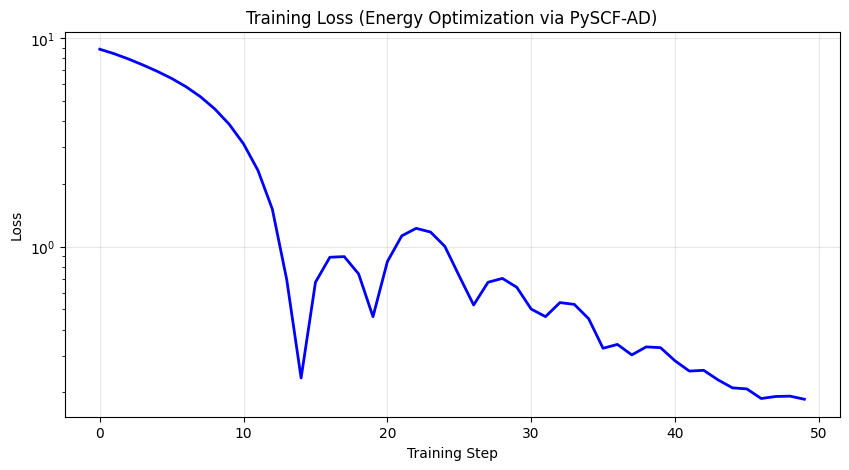

In [18]:
# Plot training progress
plt.figure(figsize=(10, 5))
plt.plot(training_losses, 'b-', linewidth=2)
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.title('Training Loss (Energy Optimization via PySCF-AD)')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Plot grid density training progress
plt.figure(figsize=(10, 5))
plt.plot(grid_density_losses, 'g-', linewidth=2)
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.title('Training Loss (Energy + Grid Density via PySCF-AD)')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

# Compare energy-only vs grid-density training
print("\n" + "="*60)
print("Comparison: Energy-only vs Energy+Grid Density Training")
print("="*60)
print(f"Energy-only final loss: {training_losses[-1]:.6f}")
print(f"Energy+Grid Density final loss: {grid_density_losses[-1]:.6f}")

In [ ]:
# Compare all training approaches
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(training_losses, label='Energy only', alpha=0.8, linewidth=2)
ax.plot(density_losses, label='Energy + DM Reg (weight=0.1)', alpha=0.8, linewidth=2)
ax.plot(density_losses_hw, label='Energy + DM Reg (weight=10.0)', alpha=0.8, linewidth=2)
ax.plot(grid_density_losses, label='Energy + Grid Density', alpha=0.8, linewidth=2)
ax.set_xlabel('Training Step')
ax.set_ylabel('Loss')
ax.set_title('Training Loss Comparison (All Methods)')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFinal losses:")
print(f"  Energy only:                    {training_losses[-1]:.6f}")
print(f"  Energy + DM Reg (weight=0.1):   {density_losses[-1]:.6f}")
print(f"  Energy + DM Reg (weight=10.0):  {density_losses_hw[-1]:.6f}")
print(f"  Energy + Grid Density:          {grid_density_losses[-1]:.6f}")

---
## Using the Trained Model with PySCF-AD

Here's how to use the trained neural network XC functional with PySCF-AD for actual DFT calculations:

In [25]:
def run_calculation_with_nn_xc(mol, xcmodel):
    '''
    Run a DFT calculation using the trained neural network XC functional.
    
    :param mol: PySCF Mole object (regular, not pyscf-ad)
    :param xcmodel: Trained XC model (RXCModel_GGA)
    :return: Converged mf object
    '''
    # Create custom eval_xc function using eval_xc_gga_j2 from xcquinox.pyscf
    eval_xc_custom = partial(eval_xc_gga_j2, xcmodel=xcmodel)
    
    # Create DFT object
    if mol.spin == 0:
        mf = dft.RKS(mol)
    else:
        mf = dft.UKS(mol)
    
    # Set custom XC functional
    mf = mf.define_xc_(eval_xc_custom, 'GGA')
    mf.grids.level = GRID_LEVEL
    
    # Run calculation
    mf.kernel()
    
    return mf

# Example: run calculation on H2O with trained model
print("\n" + "="*60)
print("Testing Trained Model on H2O")
print("="*60)

mol_h2o = create_mol('O 0 0 0; H 0 0.757 0.587; H 0 -0.757 0.587', spin=0)

try:
    mf_nn = run_calculation_with_nn_xc(mol_h2o, xcmodel_trained)
    print(f"  Neural network XC energy: {mf_nn.e_tot:.6f} Ha")
    
    # Compare with PBE
    mf_pbe = run_pbe_calculation(mol_h2o)
    print(f"  PBE reference energy: {mf_pbe.e_tot:.6f} Ha")
    print(f"  Difference: {abs(mf_nn.e_tot - mf_pbe.e_tot)*1000:.3f} mHa")
except Exception as e:
    print(f"  Note: Full SCF may require additional setup. Error: {e}")


Testing Trained Model on H2O
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape (1,)
s shape 

---
## Saving and Loading Models

In [ ]:
# Save final trained models to the final_models directory
FINAL_DIR = CHECKPOINT_DIRS['final_models']

# Save energy-trained networks
xnet_path = os.path.join(FINAL_DIR, 'xnet_energy_trained.eqx')
eqx.tree_serialise_leaves(xnet_path, xcmodel_trained.xnet)
cnet_path = os.path.join(FINAL_DIR, 'cnet_energy_trained.eqx')
eqx.tree_serialise_leaves(cnet_path, xcmodel_trained.cnet)
print(f"Saved energy-trained networks to {FINAL_DIR}/")

# Save DM-regularization-trained networks (low weight)
xnet_dm_path = os.path.join(FINAL_DIR, 'xnet_dm_reg_trained.eqx')
eqx.tree_serialise_leaves(xnet_dm_path, xcmodel_density_trained.xnet)
cnet_dm_path = os.path.join(FINAL_DIR, 'cnet_dm_reg_trained.eqx')
eqx.tree_serialise_leaves(cnet_dm_path, xcmodel_density_trained.cnet)
print(f"Saved DM-reg-trained (low weight) networks to {FINAL_DIR}/")

# Save DM-regularization-trained networks (high weight)
xnet_dm_hw_path = os.path.join(FINAL_DIR, 'xnet_dm_reg_hw_trained.eqx')
eqx.tree_serialise_leaves(xnet_dm_hw_path, xcmodel_density_trained_hw.xnet)
cnet_dm_hw_path = os.path.join(FINAL_DIR, 'cnet_dm_reg_hw_trained.eqx')
eqx.tree_serialise_leaves(cnet_dm_hw_path, xcmodel_density_trained_hw.cnet)
print(f"Saved DM-reg-trained (high weight) networks to {FINAL_DIR}/")

# Save grid-density-trained networks
xnet_grid_path = os.path.join(FINAL_DIR, 'xnet_grid_density_trained.eqx')
eqx.tree_serialise_leaves(xnet_grid_path, xcmodel_grid_density_trained.xnet)
cnet_grid_path = os.path.join(FINAL_DIR, 'cnet_grid_density_trained.eqx')
eqx.tree_serialise_leaves(cnet_grid_path, xcmodel_grid_density_trained.cnet)
print(f"Saved grid-density-trained networks to {FINAL_DIR}/")

print(f"\nAll final models saved to: {FINAL_DIR}/")
print("\nTo load the trained networks:")
print(f"  xnet_loaded = eqx.tree_deserialise_leaves('{xnet_path}', xnet_B)")
print(f"  cnet_loaded = eqx.tree_deserialise_leaves('{cnet_path}', cnet_B)")

---
## Summary

This notebook demonstrated training a GGA-level neural network XC functional using xcquinox with PySCF-AD.

### Training Approaches Compared:

1. **Pre-training**: Fit exchange (Fx) and correlation (Fc) enhancement factors to PBE reference data

2. **Energy-only training**: Fine-tune on total energies and atomization energies using SCF through pyscf-ad

3. **DM Regularization (low weight)**: Energy + density matrix norm penalty (weight=0.1)

4. **DM Regularization (high weight)**: Energy + density matrix norm penalty (weight=10.0)

5. **Grid Density training**: Energy + actual electron density error on grid (compared to PBE reference density)

### Key Implementation Details:

- **PySCF-AD integration**: Training uses `dft_ad.UKS`/`dft_ad.RKS` from pyscfad for differentiable SCF
- **Custom eval_xc function**: `eval_xc_gga_j2` wraps the neural network model for PySCF integration
- **Input format**: Networks expect single grid points `[rho, sigma]`, vmap handles batching
- **xcquinox.train.Optimizer**: Handles training loop with value-and-grad loss functions
- **Gradient clipping**: Essential for stability when backpropagating through SCF

### Key Points for Production Use:

- Use larger basis sets (e.g., `def2-SVP` or `cc-pVTZ`) for better accuracy
- Use finer grids (level=3 or higher) for production
- Pre-train on diverse molecules covering different bonding situations
- For density training, use CCSD or CCSD(T) reference densities instead of PBE
- Increase training steps and tune learning rates for full training runs
- Monitor for SCF convergence issues during training